# Mesure performance Elastic search

## CELLULE 1 — Setup et connexions

In [33]:
# ─────────────────────────────────────────────────────────────
# CELLULE 1 — Setup et connexions
# ─────────────────────────────────────────────────────────────

import sys
from pathlib import Path
import time
import json
import warnings
warnings.filterwarnings("ignore")

# Ajouter la racine au sys.path
RACINE = Path("..").resolve()
if str(RACINE) not in sys.path:
    sys.path.insert(0, str(RACINE))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

from elasticsearch import Elasticsearch
import psycopg2
from dotenv import load_dotenv
import os

load_dotenv(RACINE / ".env")

print("Imports OK")

Imports OK


## CELLULE 2 — Connexions

In [34]:
# ─────────────────────────────────────────────────────────────
# CELLULE 2 — Connexions
# ─────────────────────────────────────────────────────────────

# ── Elasticsearch ─────────────────────────────────────────────
es = Elasticsearch(
    f"http://{os.getenv('ELASTIC_HOST', 'localhost')}:{os.getenv('ELASTIC_PORT', 9200)}"
)
assert es.ping(), "Elasticsearch inaccessible"
print(f"Elasticsearch connecté — index 'offres' : {es.count(index='offres')['count']} documents")

# ── PostgreSQL ────────────────────────────────────────────────
conn = psycopg2.connect(
    host     = os.getenv("POSTGRES_HOST", "localhost"),
    port     = int(os.getenv("POSTGRES_PORT", 5432)),
    dbname   = os.getenv("POSTGRES_DB", "job_market"),
    user     = os.getenv("POSTGRES_USER"),
    password = os.getenv("POSTGRES_PASSWORD"),
)
print("PostgreSQL connecté")

Elasticsearch connecté — index 'offres' : 9079 documents
PostgreSQL connecté


## CELLULE 3 — Charger les labels ML depuis PostgreSQL

In [35]:
# ─────────────────────────────────────────────────────────────
# CELLULE 3 — Charger les labels ML depuis PostgreSQL
# ─────────────────────────────────────────────────────────────

# Récupérer toutes les offres avec leurs labels ML
df_labels = pd.read_sql("""
    SELECT
        o.id,
        o.titre,
        o.source,
        o.localisation_ville,
        o.type_contrat,
        ml.ml_keyword,
        ml.ml_label_binaire,
        ml.ml_label_categorie
    FROM offres o
    JOIN ml_labels ml ON ml.offre_id = o.id
""", conn)

print(f"Offres avec labels ML : {len(df_labels)}")
print(f"\nDistribution des labels :")
print(df_labels["ml_label_categorie"].value_counts())
print(f"\nKeywords disponibles :")
print(df_labels["ml_keyword"].unique())

Offres avec labels ML : 15048

Distribution des labels :
ml_label_categorie
non_data    7728
data        7320
Name: count, dtype: int64

Keywords disponibles :
<StringArray>
[             'data engineer',          'ingénieur données',
             'ingénieur data',           'pipeline données',
            'ETL développeur',         'architecte données',
            'architecte data',                      'MLOps',
             'data scientist',  'machine learning engineer',
 'ingénieur machine learning',               'NLP engineer',
            'computer vision',               'data analyst',
              'deep learning',           'analyste données',
           'business analyst',      'business intelligence',
                'analyste BI',               'data manager',
               'data steward',               'data quality',
            'data governance',                    'airflow',
         'chief data officer',                 'databricks',
            'spark developer',   

## CELLULE 4 — Fonctions de recherche Elasticsearch

In [36]:
# ─────────────────────────────────────────────────────────────
# CELLULE 4 — Fonctions de recherche Elasticsearch
# ─────────────────────────────────────────────────────────────

def rechercher_es(
    query:       str,
    champs:      list  = ["titre^3", "description", "competences^2"],
    nb_resultats: int  = 100,
    filtres:     dict  = None,
) -> tuple[list[str], float]:
    """
    Recherche dans Elasticsearch et retourne :
    - liste des ids retournés
    - temps d'exécution en millisecondes
    """
    body = {
        "query": {
            "bool": {
                "must": [{
                    "multi_match": {
                        "query":  query,
                        "fields": champs,
                    }
                }],
                "filter": []
            }
        },
        "size": nb_resultats,
    }

    # Ajouter les filtres optionnels
    if filtres:
        for champ, valeur in filtres.items():
            body["query"]["bool"]["filter"].append(
                {"term": {champ: valeur}}
            )

    # Mesurer le temps d'exécution
    debut = time.perf_counter()
    res   = es.search(index="offres", body=body)
    fin   = time.perf_counter()

    temps_ms  = (fin - debut) * 1000
    ids       = [h["_id"] for h in res["hits"]["hits"]]
    scores    = [h["_score"] for h in res["hits"]["hits"]]

    return ids, scores, temps_ms


def rechercher_es_bm25_boost(query: str, nb_resultats: int = 100):
    """BM25 avec pondération des champs."""
    return rechercher_es(
        query        = query,
        champs       = ["titre^3", "description", "competences^2"],
        nb_resultats = nb_resultats,
    )


def rechercher_es_titre_only(query: str, nb_resultats: int = 100):
    """Recherche sur le titre uniquement."""
    return rechercher_es(
        query        = query,
        champs       = ["titre"],
        nb_resultats = nb_resultats,
    )


def rechercher_es_tous_champs(query: str, nb_resultats: int = 100):
    """Recherche sur tous les champs avec poids égaux."""
    return rechercher_es(
        query        = query,
        champs       = ["titre", "description", "competences", "missions"],
        nb_resultats = nb_resultats,
    )

print("Fonctions de recherche définies")

Fonctions de recherche définies


## CELLULE 5 — Calcul des métriques

In [37]:
# ─────────────────────────────────────────────────────────────
# CELLULE 5 — Calcul des métriques
# ─────────────────────────────────────────────────────────────

def calculer_metriques(
    ids_retournes:  list[str],
    df_labels:      pd.DataFrame,
    label_positif:  int = 1,
) -> dict:
    """
    Calcule précision, rappel et F1 pour une liste de résultats ES.

    Principe :
        - ids_retournes : offres retournées par Elasticsearch
        - df_labels     : ground truth depuis PostgreSQL
        - label_positif : 1 = data, 0 = non-data

    Pour chaque offre retournée :
        - si elle est dans df_labels et étiquetée label_positif → vrai positif
        - si elle est dans df_labels et étiquetée autrement     → faux positif
        - offres étiquetées label_positif mais non retournées   → faux négatif
    """
    # Offres connues dans le ground truth
    ids_connus = set(df_labels["id"].values)

    # Offres retournées ET présentes dans le ground truth
    ids_evalues = [id_ for id_ in ids_retournes if id_ in ids_connus]

    if not ids_evalues:
        return {
            "precision": 0.0, "rappel": 0.0, "f1": 0.0,
            "nb_retournes": len(ids_retournes),
            "nb_evalues":   0,
            "avertissement": "Aucune offre retournée présente dans le ground truth"
        }

    # Construire y_true et y_pred
    df_eval = df_labels[df_labels["id"].isin(ids_evalues)].copy()
    df_eval = df_eval.drop_duplicates(subset="id")

    # y_pred : 1 pour toutes les offres retournées (ES les considère pertinentes)
    y_pred = [1] * len(df_eval)
    y_true = df_eval["ml_label_binaire"].tolist()

    # Offres positives non retournées → faux négatifs
    ids_positifs_ground_truth = set(
        df_labels[df_labels["ml_label_binaire"] == label_positif]["id"].values
    )
    faux_negatifs = len(ids_positifs_ground_truth - set(ids_evalues))

    # Ajouter les faux négatifs au calcul
    y_true_complet = y_true + [1] * faux_negatifs
    y_pred_complet = y_pred + [0] * faux_negatifs

    precision = precision_score(y_true_complet, y_pred_complet, zero_division=0)
    rappel    = recall_score(y_true_complet, y_pred_complet, zero_division=0)
    f1        = f1_score(y_true_complet, y_pred_complet, zero_division=0)

    return {
        "precision":      round(precision, 4),
        "rappel":         round(rappel, 4),
        "f1":             round(f1, 4),
        "nb_retournes":   len(ids_retournes),
        "nb_evalues":     len(ids_evalues),
        "vrais_positifs": int(sum(y_true)),
        "faux_positifs":  int(len(y_true) - sum(y_true)),
        "faux_negatifs":  faux_negatifs,
    }

print("Fonctions de métriques définies")

Fonctions de métriques définies


 ## CELLULE 6 — Benchmark par stratégie de recherche

In [38]:
# ─────────────────────────────────────────────────────────────
# CELLULE 6 — Benchmark par stratégie de recherche
# ─────────────────────────────────────────────────────────────

"""
# Queries de test — représentatives des métiers data
QUERIES_TEST = [
    ("data engineer",          "data"),
    ("data scientist",         "data"),
    ("machine learning",       "data"),
    ("analyste données",       "data"),
    ("développeur backend",    "non_data"),
    ("chef de projet",         "non_data"),
    ("comptable",              "non_data"),
]
"""

# Récupérer les keywords réels depuis PostgreSQL
# avec leur catégorie associée
df_keywords = df_labels[["ml_keyword", "ml_label_categorie"]]\
    .drop_duplicates()\
    .sort_values("ml_keyword")

print(f"{len(df_keywords)} keywords trouvés dans la base :\n")
print(df_keywords.to_string(index=False))

# Stratégies à comparer
STRATEGIES = {
    "BM25 boost champs": rechercher_es_bm25_boost,
    "Titre uniquement":  rechercher_es_titre_only,
    "Tous les champs":   rechercher_es_tous_champs,
}

resultats = []

for strategie, fn_recherche in STRATEGIES.items():
    print(f"\n=== Stratégie : {strategie} ===")

    for _, row in df_keywords.iterrows():
        keyword   = row["ml_keyword"]
        categorie = row["ml_label_categorie"]

        # Ground truth — offres étiquetées avec ce keyword précis
        df_gt = df_labels[df_labels["ml_keyword"] == keyword].copy()

        if df_gt.empty:
            print(f"  ⚠ Aucun label pour '{keyword}' — ignoré")
            continue

        # Recherche Elasticsearch avec ce keyword
        ids, scores, temps_ms = fn_recherche(keyword, nb_resultats=50)

        # Calcul des métriques
        metriques = calculer_metriques(ids, df_gt)

        resultats.append({
            "strategie":          strategie,
            "keyword":            keyword,
            "categorie":          categorie,
            "nb_labels_gt":       len(df_gt),
            "temps_ms":           round(temps_ms, 2),
            **metriques,
        })
        """
        print(
            f"  '{keyword}' ({categorie}) — "
            f"P={metriques['precision']:.3f} "
            f"R={metriques['rappel']:.3f} "
            f"F1={metriques['f1']:.3f} "
            f"({temps_ms:.1f}ms)"
        )
        """

df_resultats = pd.DataFrame(resultats)
print(f"\n{len(df_resultats)} évaluations effectuées")

47 keywords trouvés dans la base :

                ml_keyword ml_label_categorie
           ETL développeur               data
                     MLOps               data
              NLP engineer               data
               UX designer           non_data
    administrateur système           non_data
                   airflow               data
               analyste BI               data
          analyste données               data
           architecte data               data
        architecte données               data
       architecte solution           non_data
          business analyst               data
     business intelligence               data
   chargé de communication           non_data
            chef de projet           non_data
        chief data officer               data
                commercial           non_data
                 comptable           non_data
           computer vision               data
              data analyst               dat

## CELLULE 7 — Visualisations

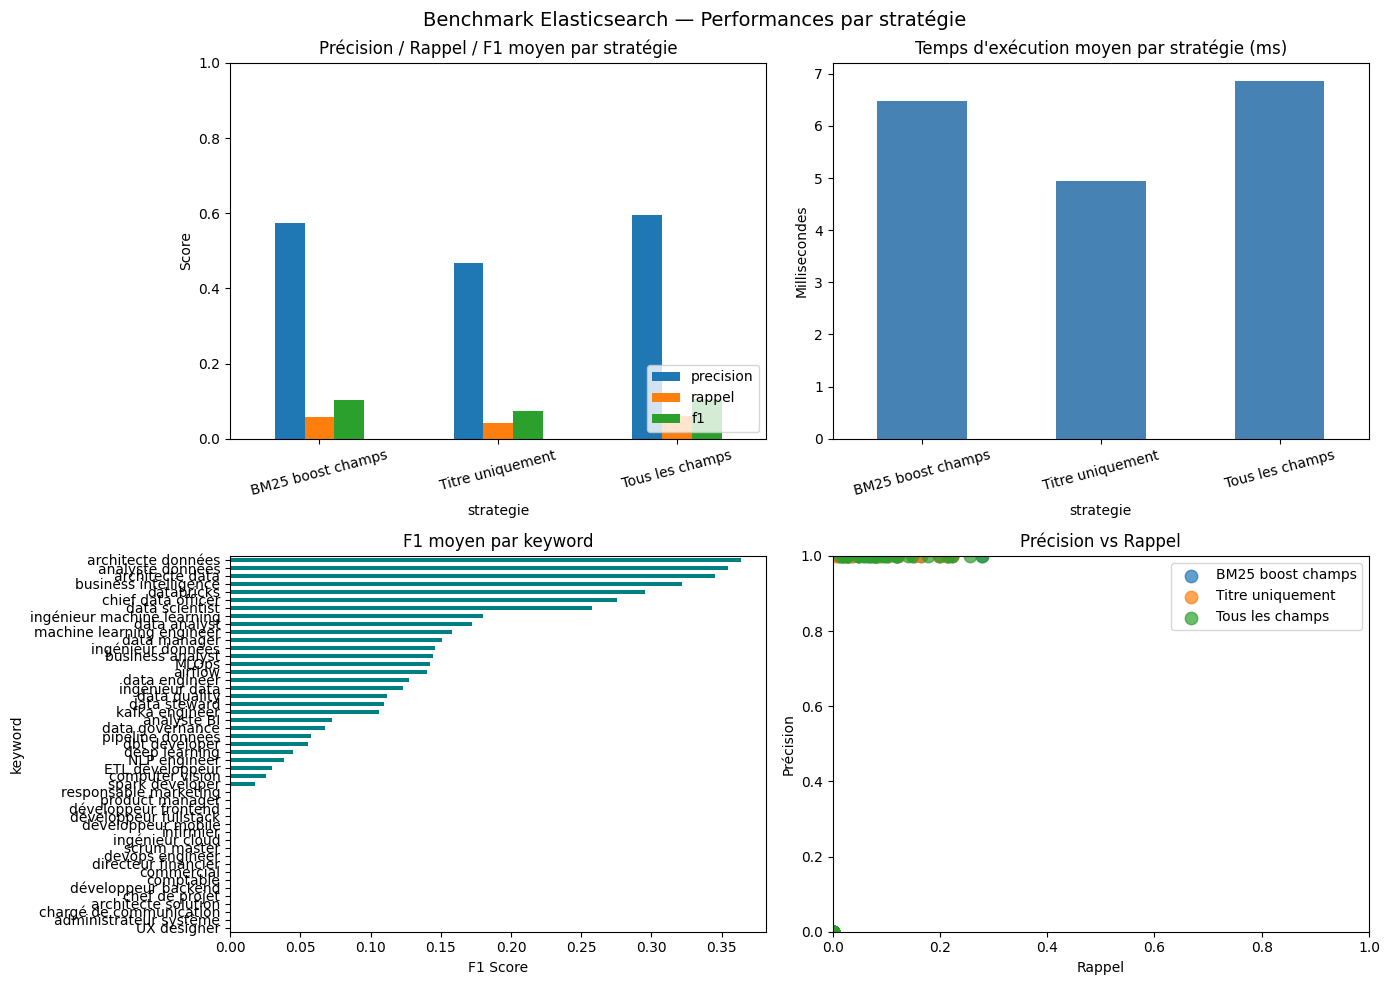

Graphiques sauvegardés → benchmark_elasticsearch.png


In [39]:
# ─────────────────────────────────────────────────────────────
# CELLULE 7 — Visualisations
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Benchmark Elasticsearch — Performances par stratégie", fontsize=14)

# ── Graphique 1 — F1 par stratégie ────────────────────────────
df_f1 = df_resultats.groupby("strategie")[["precision", "rappel", "f1"]].mean()
df_f1.plot(kind="bar", ax=axes[0, 0], rot=15)
axes[0, 0].set_title("Précision / Rappel / F1 moyen par stratégie")
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_ylim(0, 1)
axes[0, 0].legend(loc="lower right")

# ── Graphique 2 — Temps d'exécution ───────────────────────────
df_temps = df_resultats.groupby("strategie")["temps_ms"].mean()
df_temps.plot(kind="bar", ax=axes[0, 1], color="steelblue", rot=15)
axes[0, 1].set_title("Temps d'exécution moyen par stratégie (ms)")
axes[0, 1].set_ylabel("Millisecondes")

# ── Graphique 3 — F1 par keyword ────────────────────────────────
df_keywords = df_resultats.groupby("keyword")["f1"].mean().sort_values()
df_keywords.plot(kind="barh", ax=axes[1, 0], color="teal")
axes[1, 0].set_title("F1 moyen par keyword")
axes[1, 0].set_xlabel("F1 Score")

# ── Graphique 4 — Précision vs Rappel ─────────────────────────
for strategie in df_resultats["strategie"].unique():
    df_s = df_resultats[df_resultats["strategie"] == strategie]
    axes[1, 1].scatter(
        df_s["rappel"], df_s["precision"],
        label=strategie, alpha=0.7, s=80
    )
axes[1, 1].set_title("Précision vs Rappel")
axes[1, 1].set_xlabel("Rappel")
axes[1, 1].set_ylabel("Précision")
axes[1, 1].legend()
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("benchmark_elasticsearch.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphiques sauvegardés → benchmark_elasticsearch.png")

## CELLULE 7bis — F1 par keyword et par catégorie

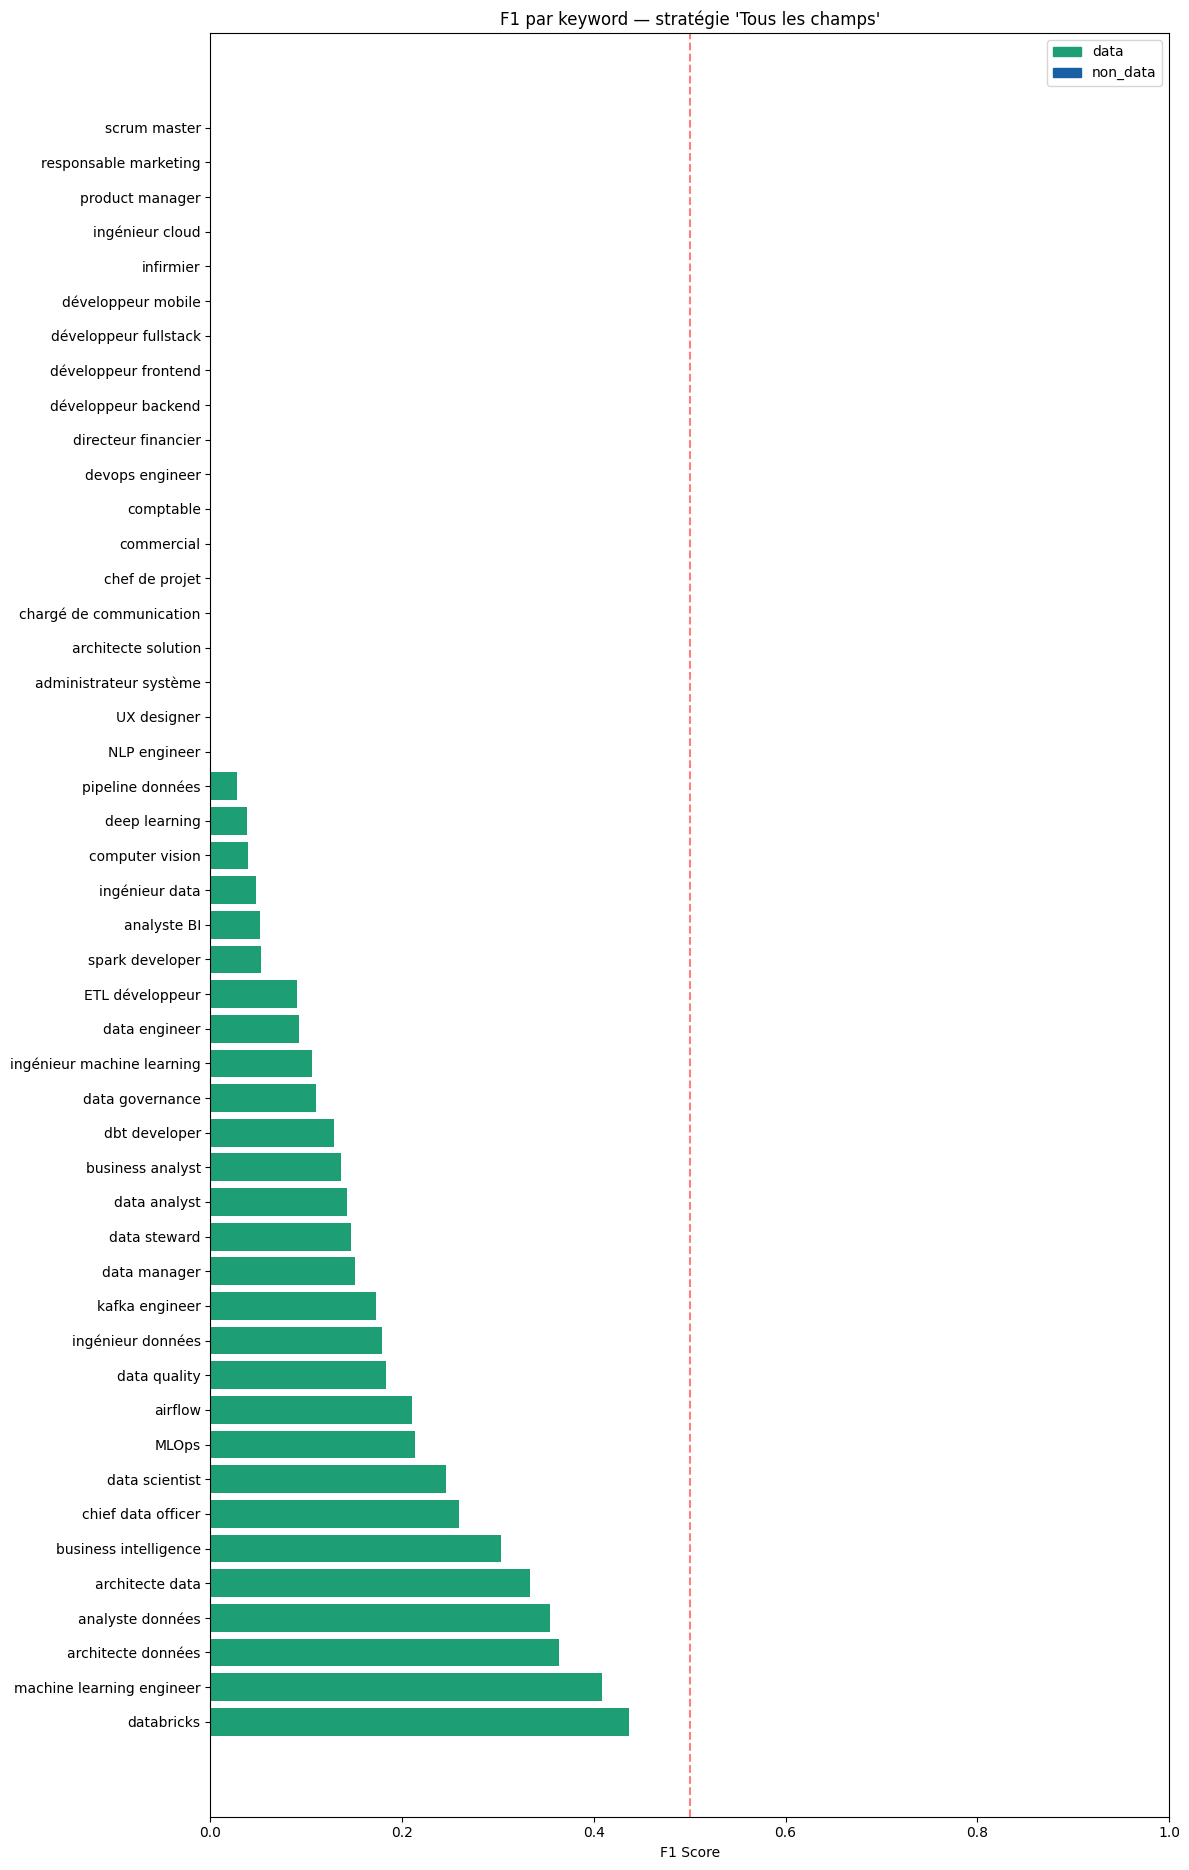

In [40]:
# ─────────────────────────────────────────────────────────────
# CELLULE 7bis — F1 par keyword et par catégorie
# ─────────────────────────────────────────────────────────────

# Prendre la meilleure stratégie
meilleure_strategie = df_resultats.groupby("strategie")["f1"].mean().idxmax()
df_best = df_resultats[df_resultats["strategie"] == meilleure_strategie].copy()

# Trier par catégorie puis F1
df_best = df_best.sort_values(["categorie", "f1"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(12, max(6, len(df_best) * 0.4)))

couleurs = df_best["categorie"].map({"data": "#1D9E75", "non_data": "#185FA5"})
bars = ax.barh(df_best["keyword"], df_best["f1"], color=couleurs)

# Légende manuelle
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#1D9E75", label="data"),
    Patch(color="#185FA5", label="non_data"),
])

ax.set_xlabel("F1 Score")
ax.set_title(f"F1 par keyword — stratégie '{meilleure_strategie}'")
ax.set_xlim(0, 1)
ax.axvline(x=0.5, color="red", linestyle="--", alpha=0.5, label="seuil 0.5")

plt.tight_layout()
plt.savefig("benchmark_par_keyword.png", dpi=150, bbox_inches="tight")
plt.show()

## CELLULE 8 — Résumé comparatif

In [41]:
# ─────────────────────────────────────────────────────────────
# CELLULE 8 — Résumé comparatif
# ─────────────────────────────────────────────────────────────

print("\n=== RÉSUMÉ DU BENCHMARK ===\n")

resume = df_resultats.groupby("strategie").agg(
    precision_moy = ("precision", "mean"),
    rappel_moy    = ("rappel",    "mean"),
    f1_moy        = ("f1",        "mean"),
    temps_moy_ms  = ("temps_ms",  "mean"),
    temps_max_ms  = ("temps_ms",  "max"),
).round(4)

print(resume.to_string())

# Meilleure stratégie
meilleure = resume["f1_moy"].idxmax()
print(f"\n→ Meilleure stratégie (F1) : {meilleure}")
print(f"  F1       : {resume.loc[meilleure, 'f1_moy']:.4f}")
print(f"  Précision: {resume.loc[meilleure, 'precision_moy']:.4f}")
print(f"  Rappel   : {resume.loc[meilleure, 'rappel_moy']:.4f}")
print(f"  Temps moy: {resume.loc[meilleure, 'temps_moy_ms']:.2f} ms")

print("""
=== INTERPRÉTATION ===

Précision = parmi les offres retournées, combien sont réellement data ?
Rappel    = parmi toutes les offres data, combien ES a-t-il retrouvé ?
F1        = moyenne harmonique précision/rappel — le score global

Ces résultats constituent la BASELINE pour évaluer le modèle ML.
Si le modèle ML ne dépasse pas ces scores, ES seul est suffisant.
""")

# Fermer les connexions
conn.close()
print("Connexions fermées.")


=== RÉSUMÉ DU BENCHMARK ===

                   precision_moy  rappel_moy  f1_moy  temps_moy_ms  temps_max_ms
strategie                                                                       
BM25 boost champs         0.5745      0.0586  0.1022        6.4881          7.95
Titre uniquement          0.4681      0.0424  0.0742        4.9438          5.79
Tous les champs           0.5957      0.0615  0.1069        6.8679          9.68

→ Meilleure stratégie (F1) : Tous les champs
  F1       : 0.1069
  Précision: 0.5957
  Rappel   : 0.0615
  Temps moy: 6.87 ms

=== INTERPRÉTATION ===

Précision = parmi les offres retournées, combien sont réellement data ?
Rappel    = parmi toutes les offres data, combien ES a-t-il retrouvé ?
F1        = moyenne harmonique précision/rappel — le score global

Ces résultats constituent la BASELINE pour évaluer le modèle ML.
Si le modèle ML ne dépasse pas ces scores, ES seul est suffisant.

Connexions fermées.
